In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
def accuracy_within_tolerance(y_true, y_pred, tolerance=0.1):
    y_true = tf.cast(y_true, tf.float32)
    diff = tf.abs((y_true - y_pred) / y_true)
    within_tolerance = tf.less_equal(diff, tolerance)
    return tf.reduce_mean(tf.cast(within_tolerance, tf.float32))

In [3]:
model = load_model(r'C:\Main project\Dataset\network_traffic_lstm_model.keras', custom_objects={'accuracy_within_tolerance': accuracy_within_tolerance})
TIMESTEPS = model.input_shape[1]  
FEATURES = model.input_shape[2]  


In [4]:
data = pd.read_csv(r'C:\Main project\Dataset\train_data.csv')

In [5]:
app_data = data.groupby('ProtocolName').agg({'PCA1': list, 'PCA2': list, 'PCA3': list}).reset_index()

In [6]:
def preprocess_input(pca1, pca2, pca3):
    pca_values = np.array([pca1, pca2, pca3]).reshape(3, 1)
    input_data = np.expand_dims(pca_values, axis=0)
    return input_data

def predict_traffic(input_data):
    prediction = model.predict(input_data)
    return max(prediction[0][0], 0)

In [7]:
def categorize_traffic(value):
    if value < 0.3:
        return 'Low Traffic'
    elif value < 0.7:
        return 'Moderate Traffic'
    else:
        return 'High Traffic'

In [8]:
predictions = {}
actual_traffic = {}
y_pred_classes = []
y_true_classes = []

for index, row in app_data.iterrows():
    app_name = row['ProtocolName']
    pca1 = row['PCA1'][0] if isinstance(row['PCA1'], list) else row['PCA1']
    pca2 = row['PCA2'][0] if isinstance(row['PCA2'], list) else row['PCA2']
    pca3 = row['PCA3'][0] if isinstance(row['PCA3'], list) else row['PCA3']

    input_data = preprocess_input(pca1, pca2, pca3)
    predicted_value = predict_traffic(input_data)
    
    # Simulating actual traffic for comparison
    actual_value = np.random.uniform(0, 1)
    
    predictions[app_name] = predicted_value
    actual_traffic[app_name] = actual_value

    # Convert values into categories for confusion matrix
    y_pred_classes.append(categorize_traffic(predicted_value))
    y_true_classes.append(categorize_traffic(actual_value))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/

In [9]:
sorted_predictions = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
top_10_high = sorted_predictions[:10]


In [10]:
print("\n📊 Top 10 Apps with Highest Predicted Traffic:")
print("{:<20} {:<15}".format("App", "Traffic Score"))
print("-" * 35)
for app, score in top_10_high:
    print("{:<20} {:.2f}".format(app, score))


📊 Top 10 Apps with Highest Predicted Traffic:
App                  Traffic Score  
-----------------------------------
TEAMSPEAK            0.76
H323                 0.76
OFFICE_365           0.76
ORACLE               0.76
DROPBOX              0.75
CITRIX               0.75
YOUTUBE              0.74
SKINNY               0.72
SSH                  0.71
TEAMVIEWER           0.69



✅ Showing Traffic Bar Graph for 'TELEGRAM'


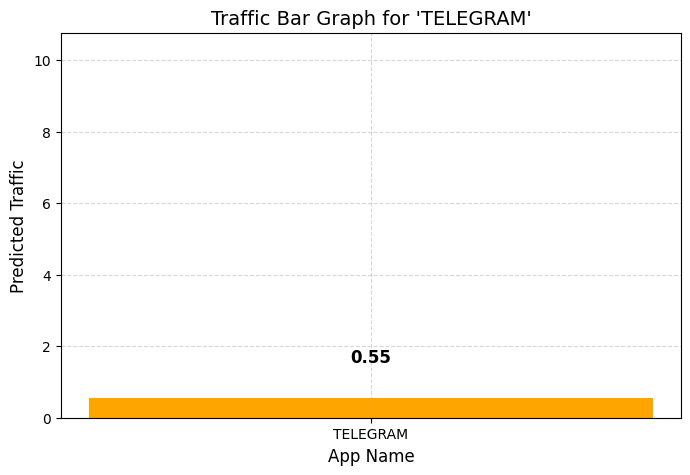

In [12]:
user_input = input("\n🔍 Enter App Name to Check Traffic (e.g., GOOGLE): ").strip().upper()

if user_input in predictions:
    print(f"\n✅ Showing Traffic Bar Graph for '{user_input}'")
    
    # Bar graph data
    x_values = [user_input]
    y_values = [predictions[user_input]]
    
    plt.figure(figsize=(8, 5))
    plt.bar(x_values, y_values, color='orange', width=0.5)

    # X and Y labels, title, and grid
    plt.xlabel("App Name", fontsize=12)
    plt.ylabel("Predicted Traffic", fontsize=12)
    plt.title(f"Traffic Bar Graph for '{user_input}'", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Set Y-Axis limit for better visualization
    plt.ylim(0, max(predictions.values()) + 10)

    # Annotate the traffic value on top of the bar
    plt.text(user_input, predictions[user_input] + 1, f"{predictions[user_input]:.2f}", 
             ha='center', fontsize=12, fontweight='bold')

    plt.show()

else:
    print(f"\n❌ App '{user_input}' not found in the dataset.")